### Preamble

In [ ]:
%load_ext autoreload
%autoreload 2

import os, pickle

# make sure the results directory exists
os.makedirs('results', exist_ok=True)

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from traffic_scheduling.single.util import set_plot_defaults
set_plot_defaults()

from traffic_scheduling.single.basics import generate_instance, uniform

# Mixed-integer linear programming benchmark (progress)

We measure the progress of the MILP solver for different selections of cutting planes. We plot the gap (in percent) as a function of time, for each instance and selection of cutting planes.

We define benchmark sets, one with `small` instances containing 2 lanes of 20 vehicles and one with `large` instances containing 3 lanes of 20 vehicles, run the benchmark on both sets and plot the results.

To keep the total benchmark time manageable, we set a time limit of 4 seconds per instance the `small` benchmark and 60 seconds per instance for the `large` benchmark.

Intermediate results and figures are stored in:

- `results/milp-bench-{small,large}.pkl`
- `results/figures/milp-bench-{small,large}.pdf`

In [5]:
def bench(name, instances, timelimit=20):
    options={'recordprogress': True, 'timelimit': timelimit}
    s_plain  = [s.solve(cutting_planes=[],     **options) for s in instances]
    s_cuts2  = [s.solve(cutting_planes=[2],    **options) for s in instances]
    s_cuts3  = [s.solve(cutting_planes=[3],    **options) for s in instances]
    s_cuts23 = [s.solve(cutting_planes=[2, 3], **options) for s in instances]
    with open(f"results/milp-bench-{name}.pkl", "wb") as file:
        pickle.dump([s_plain, s_cuts2, s_cuts3, s_cuts23], file)

In [ ]:
def plot(name):
    with open(f"results/milp-bench-{name}.pkl", "rb") as file:
        s_plain, s_cuts2, s_cuts3, s_cuts23 = pickle.load(file)

    plt.figure(figsize=(8,5))

    for schedules, color, line in zip([s_plain, s_cuts2, s_cuts3, s_cuts23], \
                                      ['black', 'blue', 'red', 'indigo'], \
                                      [':', '-.', '--', '-']):
        for s in schedules:
            plt.plot(s.progress["time"], s.progress["gap_percent"], \
                     linestyle=line, color=color, linewidth=1.0, label=color)

    plt.xlabel("Time (s)", fontsize=12)
    plt.ylabel(r"Gap ($\%$)", fontsize=12)
    # plt.title("Integer programming progress", fontsize=13)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.legend()

    plt.legend(handles=[
        mlines.Line2D([], [], color=color, linestyle=line, alpha=0.7, label=label)
        for color, label, line in zip(['black', 'blue', 'red', 'indigo'], \
                                      ['plain', 'conj', 'disj', 'conj+disj'], \
                                      [':', '-.', '--', '-'])
    ])

    plt.savefig(f"results/figures/milp-bench-{name}.pdf")
    plt.show()

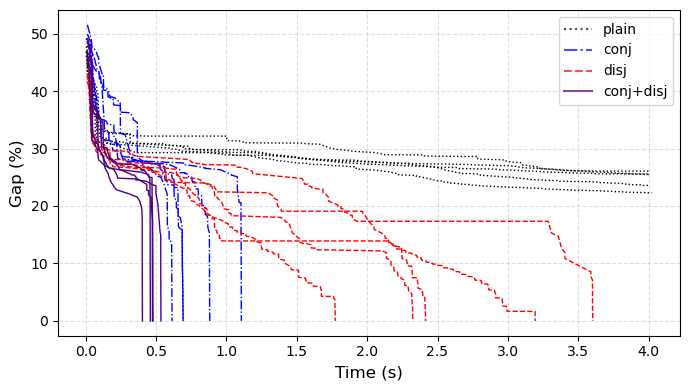

In [ ]:
N = 5
F = uniform(0, 1)
instances = [generate_instance(F, n=[20, 20]) for _ in range(N)]
bench("small", instances, timelimit=4)
plot("small")

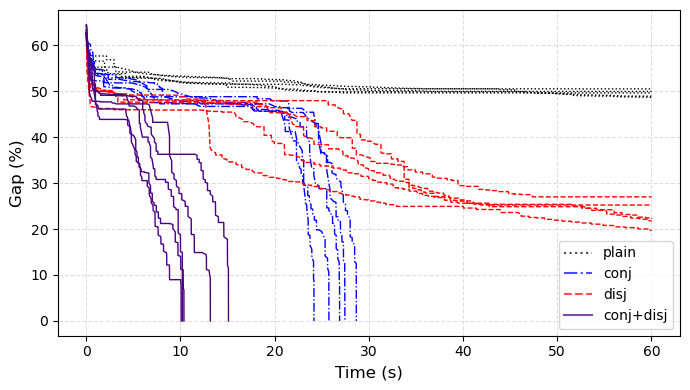

In [ ]:
N = 5
F = uniform(0, 1)
instances = [generate_instance(F, n=[20, 20, 20]) for _ in range(N)]
bench("large", instances, timelimit=60)
plot("large")